Вариант задания определяется согласно предложенному скрипту:

In [1]:
surname = "Новиков"  # Ваша фамилия

alph = 'абвгдеёжзийклмнопрстуфхцчшщъыьэюя'
w = [4, 42, 21, 21, 55,  1, 44, 26, 18, 3, 38, 26, 18, 12,  3, 49, 45,
        7, 42, 9,  4,  3, 36, 33, 31, 29,  5, 4,  4, 19, 21, 27, 33]
d = dict(zip(alph, w))
variant =  sum([d[el] for el in surname.lower()]) % 40 + 1

print("Задание № 2. Вариант: ", variant % 2 + 1)
print("Задание № 3. Вариант: ", variant % 3 + 1 )

Задание № 2. Вариант:  2
Задание № 3. Вариант:  2


# Задача 1. Реализация собственных классов и функций

## 1 пункт
Реализовать класс, предназначенный для оценки параметров линейной регрессии с регуляризацией совместимый с `sklearn`. 

Передаваемые параметры: 
1. коэффициент регуляризации (*alpha*). 

Использовать **метод наименьших квадратов с регуляризацией**.

Подключаем необходимые библиотеки:

In [2]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.base import BaseEstimator, RegressorMixin, TransformerMixin
from sklearn.utils.validation import check_X_y, check_array, check_is_fitted

Определим класс, реализующий ридж-регрессию (*формула известна*).

Класс будет оценивать параметры линейной регрессии с заданной регуляризацией.

Родительским для нашего класса будут: 
* `BaseEstimator` - базовый для всех моделей в sklearn
* `RegressorMixin` - это добавка, которая говорит: "модель — это регрессор"

In [3]:
class CustomLinearRegression(BaseEstimator, RegressorMixin):
    
    def __init__(self, alpha=1.0, method='ridge'):
        self.alpha = alpha
        self.method = method
    
    def fit(self, X, y):
        X_b = np.hstack([np.ones((X.shape[0], 1)), X])
        n_features = X_b.shape[1]
        I = np.eye(n_features)
        I[0, 0] = 0
        self.coef_ = np.linalg.inv(X_b.T @ X_b + self.alpha * I) @ X_b.T @ y
        return self

    def predict(self, X):
        X_b = np.hstack([np.ones((X.shape[0], 1)), X])
        return X_b @ self.coef_

Теперь проверим написаный класс на практике. 
Для этого подготовим данные, с которыми будем работать

In [4]:
def generate_data(n=100, start_x=4, length_x=8, mu=0, sigma=0.5):
    """Генерация данных."""
    from scipy import stats
    f = lambda x: 2 + 0.3*x
    x = stats.uniform.rvs(size=n, loc=start_x, scale=length_x, random_state=1)
    e = stats.norm.rvs(size=n, loc=mu, scale=sigma, random_state=1)
    return x.reshape(-1,1), f(x) + e

In [5]:
def plot_regression(X, y, model=None):
    """
    Функция для отображения наблюдений и линии регрессии.

    Parameters:
    X : numpy array, shape (n_samples, n_features)
        Входные данные (матрица признаков).
    y : numpy array, shape (n_samples,)
        Целевые значения (метки).
    model : объект модели, который имеет метод predict
        Модель, предсказывающая значения для регрессионной линии.
    """
    plt.figure(2, figsize=[4, 4])
    
    xx = np.linspace(X[:, 0].min(), X[:, 0].max(), 2).reshape(-1, 1)

    plt.subplot(1, 1, 1)
    plt.scatter(X[:, 0], y, color="green", label="Sample", zorder=2)
    if model:
        plt.plot(xx, model.predict(xx), "-", color="grey", label="Regression")
    plt.xlabel("$x$")
    plt.ylabel("$f(x)$")
    plt.legend()
    plt.grid(True)
    plt.show()

In [6]:
X, y = generate_data()

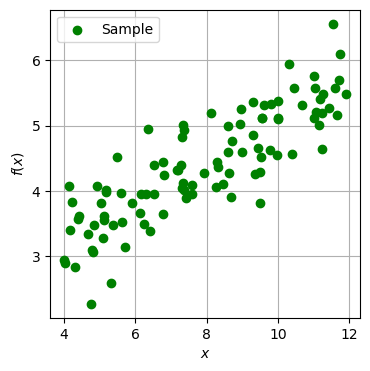

In [7]:
# Отображение наблюдений
plot_regression(X, y)

In [8]:
from sklearn.model_selection import train_test_split

In [9]:
# Разбиение данных на обучающие и тестовые
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=10)
X_train[:5], y_train[:5]

(array([[6.24355194],
        [9.53501691],
        [6.15942313],
        [5.69302493],
        [6.52412505]]),
 array([3.49948643, 4.52488201, 3.9469768 , 3.13664838, 3.95090521]))

In [10]:
model = CustomLinearRegression()

In [11]:
# Обучение
model.fit(X_train, y_train)
model.coef_

array([1.90471493, 0.30801062])

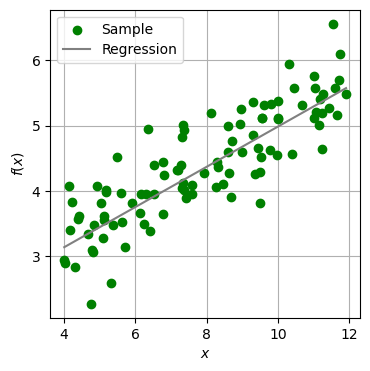

In [12]:
# Отображение наблюдений и линии регрессии
plot_regression(X, y, model)

In [13]:
model.score(X_test, y_test)

0.7111923560425134

как видно, получена точность 70%

## 2 пункт

Реализовать класс, предназначенный для для стандартизации признаков в виде трансформации совместимый с `sklearn`. 

Передаваемые параметры: 
1. has_bias (содержит ли матрица вектор единиц), 
2. apply_mean (производить ли центровку)

In [14]:
class CustomStandardScaler(BaseEstimator, TransformerMixin):
    def __init__(self, has_bias=False, apply_mean=True):
        self.has_bias = has_bias
        self.apply_mean = apply_mean

    def fit(self, X, y=None):
        X = check_array(X)

        start_col = 1 if self.has_bias else 0
        self.mean_ = np.zeros(X.shape[1])
        self.std_ = np.ones(X.shape[1])

        if self.apply_mean:
            self.mean_[start_col:] = np.mean(X[:, start_col:], axis=0)
        self.std_[start_col:] = np.std(X[:, start_col:], axis=0, ddof=0)

        return self

    def transform(self, X):
        check_is_fitted(self, ["mean_", "std_"])
        X = check_array(X)

        X_scaled = (X - self.mean_) / self.std_
        if self.has_bias:
            X_scaled[:, 0] = X[:, 0]  # не трогаем bias-столбец

        return X_scaled

Создадим экземпляр нового класса:

In [15]:
scaler = CustomStandardScaler()

In [16]:
# Стандартизируем данные
scaler.fit(X)
X_scaled = scaler.transform(X)
# Отображение X
print("Исходные данные X:")
print(X[:5])

print("\nСтандартизированные данные X_scaled:")
print(X_scaled[:5])

Исходные данные X:
[[7.33617604]
 [9.76259595]
 [4.000915  ]
 [6.41866058]
 [5.17404713]]

Стандартизированные данные X_scaled:
[[-0.23388437]
 [ 0.79634961]
 [-1.65000333]
 [-0.62345239]
 [-1.15190299]]


## 3 пункт

Реализуйте функции для расчета MSE и R^2 при отложенной выборке (run_holdout) и кросс-валидации (run_cross_val). Для кросс-валидации используйте только класс KFold. Выходными значениями должны быть MSE и R^2 для обучающей и тестовой частей.

Реализовать функции для расчета:
* MSE 
* R^2 

при: 
* отложенной выборке (run_holdout)
* кросс-валидации (run_cross_val) 

Для кросс-валидации используйте только класс KFold.
Выходными значениями должны быть MSE и R^2 для обучающей и тестовой частей.

In [17]:
import numpy as np
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import mean_squared_error, r2_score

def run_holdout(model, X, y, train_size, random_state) -> dict:
    """
    Функция для расчета MSE и R^2 на отложенной выборке (holdout).
    
    Parameters:
    model : объект модели с методами fit и predict
        Модель, которая обучается и делает предсказания.
    X : numpy array, shape (n_samples, n_features)
        Входные данные (матрица признаков).
    y : numpy array, shape (n_samples,)
        Целевые значения (метки).
    train_size : float
        Доля данных для обучения (от 0 до 1).
    random_state : int
        Сеятель для случайных операций (например, для разделения данных).
    
    Returns:
    dict : словарь с MSE и R^2 для обучающей и тестовой выборки
    """
    # Разделение на обучающую и тестовую выборки
    X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=train_size, random_state=random_state)

    # Обучение модели
    model.fit(X_train, y_train)

    # Предсказания для обучающей выборки
    y_train_pred = model.predict(X_train)
    # Предсказания для тестовой выборки
    y_test_pred = model.predict(X_test)

    # Вычисление MSE и R^2 для обучающей выборки
    mse_train = mean_squared_error(y_train, y_train_pred)
    r2_train = r2_score(y_train, y_train_pred)

    # Вычисление MSE и R^2 для тестовой выборки
    mse_test = mean_squared_error(y_test, y_test_pred)
    r2_test = r2_score(y_test, y_test_pred)

    # Возвращаем результаты в виде словаря
    scores = {
        "train_mse": mse_train,
        "train_r2": r2_train,
        "test_mse": mse_test,
        "test_r2": r2_test
    }

    return scores

In [18]:
def run_cross_val(model, X, y, n_splits, shuffle, random_state) -> dict:
    """
    Функция для расчета MSE и R^2 при кросс-валидации с использованием KFold.
    
    Parameters:
    model : объект модели с методами fit и predict
        Модель, которая обучается и делает предсказания.
    X : numpy array, shape (n_samples, n_features)
        Входные данные (матрица признаков).
    y : numpy array, shape (n_samples,)
        Целевые значения (метки).
    n_splits : int
        Количество разбиений для кросс-валидации.
    shuffle : bool
        Нужно ли перемешивать данные перед разбиением.
    random_state : int
        Сеятель для случайных операций.
    
    Returns:
    dict : словарь с MSE и R^2 для обучающей и тестовой частей
    """
    # KFold для кросс-валидации
    kf = KFold(n_splits=n_splits, shuffle=shuffle, random_state=random_state)

    # Списки для хранения значений MSE и R^2
    mse_train_list = []
    r2_train_list = []
    mse_test_list = []
    r2_test_list = []

    # Кросс-валидация
    for train_index, test_index in kf.split(X):
        X_train, X_test = X[train_index], X[test_index]
        y_train, y_test = y[train_index], y[test_index]

        # Обучение модели
        model.fit(X_train, y_train)

        # Предсказания для обучающей выборки
        y_train_pred = model.predict(X_train)
        # Предсказания для тестовой выборки
        y_test_pred = model.predict(X_test)

        # Вычисление MSE и R^2 для обучающей выборки
        mse_train = mean_squared_error(y_train, y_train_pred)
        r2_train = r2_score(y_train, y_train_pred)

        # Вычисление MSE и R^2 для тестовой выборки
        mse_test = mean_squared_error(y_test, y_test_pred)
        r2_test = r2_score(y_test, y_test_pred)

        # Добавляем результаты в списки
        mse_train_list.append(mse_train)
        r2_train_list.append(r2_train)
        mse_test_list.append(mse_test)
        r2_test_list.append(r2_test)

    # Средние значения для MSE и R^2
    scores = {
        "mean_train_mse": np.mean(mse_train_list),
        "mean_train_r2": np.mean(r2_train_list),
        "mean_test_mse": np.mean(mse_test_list),
        "mean_test_r2": np.mean(r2_test_list)
    }

    return scores

Протестируем функции на практике:

In [21]:
# Примерные данные X и y
# X = np.random.rand(100, 2)
# y = np.random.rand(100)

# Отложенная выборка
holdout_scores = run_holdout(model, X, y, train_size=0.8, random_state=42)
print("Holdout Scores:\n", holdout_scores, "\n\n")

# Кросс-валидация
cross_val_scores = run_cross_val(model, X, y, n_splits=5, shuffle=True, random_state=42)
print("Cross-validation Scores:\n", cross_val_scores)


Holdout Scores:
 {'train_mse': 0.2006073113105494, 'train_r2': 0.7339481247612261, 'test_mse': 0.18123597094811056, 'test_r2': 0.6267901195830985} 


Cross-validation Scores:
 {'mean_train_mse': 0.19428087343519773, 'mean_train_r2': 0.7215030554708867, 'mean_test_mse': 0.2101665946262073, 'mean_test_r2': 0.6738807716395934}


## 4 пункт

Используя класс `Pipeline`, выполнить обучение линейной регрессии с предварительной стандартизацией с коэффициентом регуляризации равным 0 и 0.01. 
* Вывести значения параметров обученной модели. 
* Вывести значения `MSE` и `R^2`, полученные посредством функций `run_holdout` и `run_cross_val`. 
* Отобразить график **предсказание - действительное значение** для разных коэффициентов регуляризации для обучающего и текстового множества. 

Использовать следующие параметры:

- train_size=0.75,
- n_splits=4,
- shuffle=True,
- random_state=0

⚠️ Замечание. При формировании исходных данных использовался полином 16 степени одномерных данных.

In [23]:
from sklearn.pipeline import Pipeline


=== Alpha = 0 ===
Коэффициенты модели: [4.39639845 0.71114223]

Holdout:
{'train_mse': 0.20403517416841843, 'train_r2': 0.6882911818517201, 'test_mse': 0.1904719903557419, 'test_r2': 0.746395386565615}
Cross-validation:
{'mean_train_mse': 0.19403883229355276, 'mean_train_r2': 0.7214168974847806, 'mean_test_mse': 0.20873592398349344, 'mean_test_r2': 0.6807279641713322}


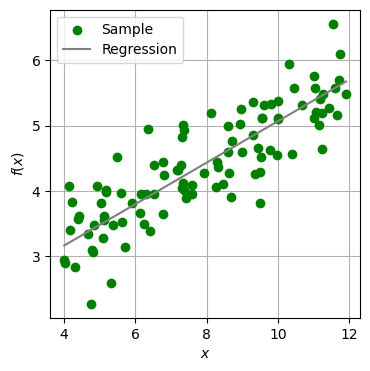


=== Alpha = 0.01 ===
Коэффициенты модели: [4.39639845 0.71107112]

Holdout:
{'train_mse': 0.2040351821757872, 'train_r2': 0.6882911696186949, 'test_mse': 0.1905135407848552, 'test_r2': 0.7463400640980247}
Cross-validation:
{'mean_train_mse': 0.19403884124792353, 'mean_train_r2': 0.7214168846630107, 'mean_test_mse': 0.20873475751402057, 'mean_test_r2': 0.680735898099181}


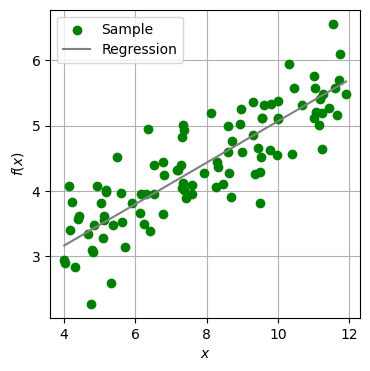

In [25]:
alphas = [0, 0.01]
train_size = 0.75
n_splits = 4
shuffle = True
random_state = 0

for alpha in alphas:
    print(f"\n=== Alpha = {alpha} ===")
    
    pipeline = Pipeline([
        ('scaler', CustomStandardScaler(has_bias=False, apply_mean=True)),
        ('customlinearregression', CustomLinearRegression(alpha=alpha))
    ])
    
    # --- Обучение
    pipeline.fit(X, y)
    
    # --- Коэффициенты
    coef = pipeline.named_steps['customlinearregression'].coef_
    print(f"Коэффициенты модели: {coef}\n")
    
    # --- Метрики: Holdout
    holdout_scores = run_holdout(pipeline, X, y, train_size, random_state)
    print("Holdout:")
    print(holdout_scores)
    
    # --- Метрики: Cross-validation
    cv_scores = run_cross_val(pipeline, X, y, n_splits, shuffle, random_state)
    print("Cross-validation:")
    print(cv_scores)
    
    # --- График
    plot_regression(X, y, pipeline)